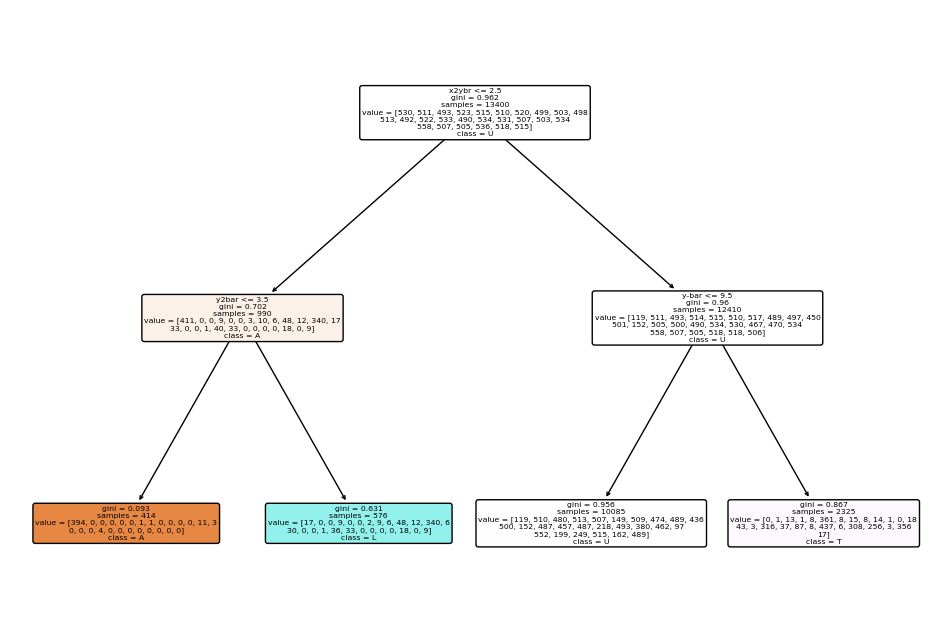

In [2]:
from scipy.io import arff
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree
import matplotlib.pyplot as plt

# Load ARFF file
arff_file_path = 'dataset_6_letter.arff'  
data, meta = arff.loadarff(arff_file_path)

# Convert data to a Pandas DataFrame
df = pd.DataFrame(data)
#in this Pandas dataframe, the column lables are each of the features (16 in total), the final column is the class of letter, and everything 
#in the other columns is the feature value for each sample, ir observation. In order to utalize a pandas datafram, I need to create a 
#2D array (list of list) consisting of a list of every feature value in each sample: [[ft1,ft2,ft3...],[ft1,ft2,ft3...],...]
#This 2d array will be X. 
#y will be the class lable that correspods to each of the samples, or lists of features. y will be a array in the form [class1, class2, class3, ...].
#I now need to disect the data from the pandas dataframe. 

Features = []
Classes = []
for i in range(20000):
    row_as_list = df.iloc[i].tolist()
    Classes.append(row_as_list[16])
    del row_as_list[16]
    Features.append(row_as_list)    

X, y = Features, Classes

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)
#random_state sets the random seed. That way, the results are reproducable. 

# Create a decision tree classifier
clf = DecisionTreeClassifier(max_depth=2)

# Train the classifier on the training data
clf.fit(X_train, y_train)

class_names = ['A','B','C','D','E','F','G','H','I','J','K','L','M','N','O','P','Q','R','S','T','U','V','W','X','Y','Z']
feature_names = ['x-box','y-box','width','height','onpix','x-bar','y-bar','x2bar','y2bar','xybar','x2ybr','xy2br','x-ege','xegvy','y-ege','yegvx']

#Plot the decision tree
fig, ax = plt.subplots(figsize=(12, 8))
tree.plot_tree(clf, filled=True, feature_names=feature_names, class_names=class_names, rounded=True)
plt.show()


In [9]:
from sklearn.model_selection import cross_val_score, KFold
import numpy as np

mean_error_list = []
std_dev_error_list = []


for i in range(10):
    
    # Define the number of folds for cross-validation. This will take one tenth of the data and train/test the decition tree on it.
    #It will then iterate through and train/test with the other 9/10ths of the data. 
    kfold = KFold(n_splits=10, shuffle=True, random_state=42)

    # Perform cross-validation
    scores = cross_val_score(clf, X, y, cv=kfold, scoring='accuracy')

    # Calculate mean and standard deviation of the errors
    mean_error = np.mean(scores)
    std_dev_error = np.std(scores)
    mean_error_list.append(mean_error)
    std_dev_error_list.append(std_dev_error)

total0 = 0
total1 = 0
for num0 in mean_error_list:
    total0 += num0
for num1 in std_dev_error_list:
    total1 += num1

Average_mean_error = total0/10
Average_std_dev_error = total1/10

print("Mean Error Average (10):", Average_mean_error)
print("Standard Deviation of Error Average (10):", Average_std_dev_error)
#This code calculates 10, 10-fold cross-validation experements and everages their values for the mean error and standard deviation




Mean Error Average (10): 0.12759999999999996
Standard Deviation of Error Average (10): 0.00743236167042482
